In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv('housing.csv')
dataset

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
dataset.shape

(20640, 10)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# total_rooms

Q1 = 1447.75
Q3 = 3148

IQR = Q3 - Q1
print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("lower_bound: ", lower_bound)
print("upper_bound: ", upper_bound)

1700.25
lower_bound:  -1102.625
upper_bound:  5698.375


In [7]:
# median_house_value

Q1 = 119600
Q3 = 264725

IQR = Q3 - Q1
print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("lower_bound: ", lower_bound)
print("upper_bound: ", upper_bound)

145125
lower_bound:  -98087.5
upper_bound:  482412.5


In [8]:
outliers = dataset[(dataset["median_house_value"] > upper_bound) | (dataset["median_house_value"] < lower_bound)]

print("Number of outliers:", len(outliers))


Number of outliers: 1071


In [9]:
numeric_cols = dataset.select_dtypes(include="number").columns

for col in numeric_cols:

    print("column: ", col)

    Q1 = np.quantile(dataset[col], q = 0.25)
    Q3 = np.quantile(dataset[col], q = 0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset[(dataset[col] > upper_bound) | (dataset[col] < lower_bound)]
    print("Number of outliers:", len(outliers))
    print()

column:  longitude
Number of outliers: 0

column:  latitude
Number of outliers: 0

column:  housing_median_age
Number of outliers: 0

column:  total_rooms
Number of outliers: 1287

column:  total_bedrooms
Number of outliers: 0

column:  population
Number of outliers: 1196

column:  households
Number of outliers: 1220

column:  median_income
Number of outliers: 681

column:  median_house_value
Number of outliers: 1071



In [10]:
dataset.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
dataset["ocean_proximity"].value_counts(normalize=True)

ocean_proximity
<1H OCEAN     0.442636
INLAND        0.317393
NEAR OCEAN    0.128779
NEAR BAY      0.110950
ISLAND        0.000242
Name: proportion, dtype: float64

In [12]:
dataset.duplicated().sum()

0

## Visualization


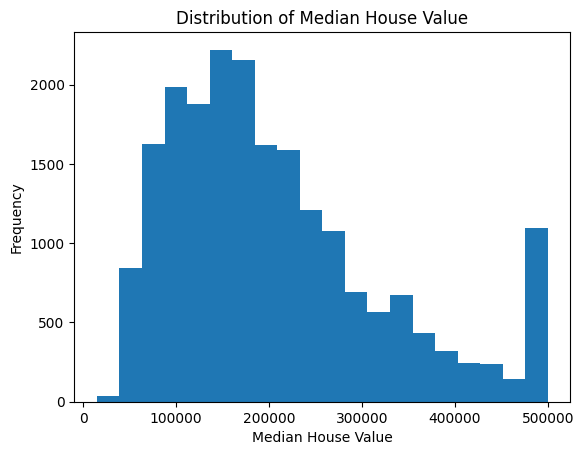

In [13]:
plt.hist(dataset["median_house_value"],bins= 20)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")
plt.show()

<div dir="rtl">

### تحلیل

۱. بیشترین تراکم داده‌ها در محدوده حدود **100,000 تا 200,000 دلار** مشاهده می‌شود و ارتفاع برخی binها به بیش از 2000 رسیده است.

۲. تجمع داده‌ها در بازه حدود **50,000 تا 300,000 دلار** است.

۳. در انتهای توزیع، تجمع قابل‌توجهی از مقادیر نزدیک به سقف **500,000 دلار** دیده می‌شود که نشان می‌دهد مقدار `500001` در داده‌ها به‌طور غیرعادی پرتکرار است.

</div>

<div dir="ltr">

### Analysis

1. The highest concentration of data is observed in the range of approximately **$100,000 to $200,000**, with the frequency of some bins exceeding 2,000.

2. Most of the data is concentrated in the range of approximately **$50,000 to $300,000**.

3. At the upper end of the distribution, there is a notable concentration of values close to the **$500,000** ceiling, indicating that the value `500001` occurs unusually frequently in the dataset.

</div>

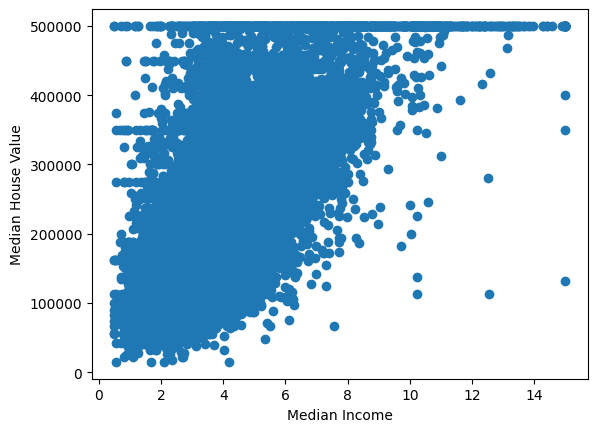

In [17]:
plt.scatter(dataset["median_income"],dataset["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

<div dir="rtl">

### تحلیل

از نمودار می‌توانیم بگوییم بین **median_income** و **median_house_value** یک رابطه مثبت دیده می‌شود. یعنی به‌طور کلی، با افزایش درآمد میانه، ارزش میانه خانه نیز تمایل به افزایش دارد.

بیشترین تراکم مشاهدات در محدوده درآمد تقریباً 2 تا 8 و ارزش خانه حدود 100,000 تا 400,000 دلار مشاهده می‌شود.

چیزی که نمودار واقعاً نشان می‌دهد این است که در درآمدهای بالاتر از حدود '11'، تعداد مشاهدات کمتر می‌شود و رابطه بین درآمد و ارزش خانه پراکنده‌تر است.

</div>

<div dir="ltr">

### Analysis

1. A positive relationship can be observed between `median_income` and `median_house_value`. In general, higher median income is associated with higher median house values.

2. Most observations are concentrated in the range of approximately **2 to 8** for median income and **$100,000 to $400,000** for median house value.

3. For median income values above approximately **11**, the number of observations decreases and the relationship becomes more dispersed. Therefore, the scatter plot alone does not provide sufficient evidence to conclude that higher income no longer leads to higher house values.

4. A notable concentration of observations can be seen at the upper limit of **$500,001**, which is consistent with the unusual frequency of this value observed during the outlier analysis.

`=> A positive association can be observed between median income and median house value. In general, higher median income is associated with higher median house values.`

</div>